# Import library

In [1]:
import os
import json
import time
import zipfile
import datetime
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torchvision import datasets, transforms, models

In [2]:
from utilis import Utility, Data, Visualization, Score, save_config_and_lr, load_config_and_lr
from chunk_handle import get_chunk_indices, iter_chunks, compute_global_image_stats, compute_global_label_stats, save_transform_and_scaler_ViT, load_transform_and_scaler_ViT

/blue/dforte/trung.le/misc/Neurips2025_Weak_lensing/utilis.py:408: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  DEVICE = "mps" if torch.has_mps else "cpu"


In [3]:
# chunk_dir= "./dataset/chunk_kappa_noise_new"
# indices=np.arange(10)
# means, stds=compute_global_image_stats(chunk_dir, indices)
# label_scaler=compute_global_label_stats(chunk_dir, indices)

In [4]:
from utilis import Utility, Data, Visualization, Score
from chunk_handle import get_chunk_indices, iter_chunks, compute_global_image_stats, compute_global_label_stats, save_transform_and_scaler, load_transform_and_scaler

In [5]:
# from torchvision import transforms
# transform = transforms.Compose([
#     transforms.ToTensor(),     
#     transforms.Normalize(mean=[means], std=[stds]),   
# ])
# print(f"Image stats (from train set): Mean={means}, Std={stds}")
# print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

# save_transform_and_scaler(means, stds, label_scaler, transform_file='./side_module/transform_params.pkl', scaler_file='./side_module/label_scaler.pkl')

# If the transform and scaler is avaiable, ignore that

In [6]:
transform, label_scaler = load_transform_and_scaler(transform_file='./side_module/transform_params.pkl', scaler_file='./side_module/label_scaler.pkl')


Loaded transform with Mean=-0.00016638042870908976, Std=0.02047532983124256
Loaded label scaler with Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]


In [7]:
# transform, label_scaler = load_transform_and_scaler_ViT(256,transform_file='./side_module_ViT/transform_params.pkl', scaler_file='./side_module_ViT/label_scaler.pkl')

# Model architecture

In [8]:
# Simple CNN architecture for parameter estimation

class Simple_CNN(nn.Module):
    def __init__(self, height, width, num_targets):
        super(Simple_CNN, self).__init__()
        # Convolutional layers
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self._feature_size = self._get_conv_output_size(height, width)
        
        # Fully connected layers (regressor head)
        self.fc_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._feature_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_targets)
        )

    def _get_conv_output_size(self, height, width):
        dummy_input = torch.zeros(1, 1, height, width)
        output = self.conv_stack(dummy_input)
        return int(np.prod(output.size()))

    def forward(self, x):
        x = self.conv_stack(x)
        x = self.fc_stack(x)
        return x  # Note that means and sigmas here have to be rescaled properly due to standardization

In [9]:
# Simple CNN architecture for parameter estimation

class Simple_CNN(nn.Module):
    def __init__(self, height, width, num_targets):
        super(Simple_CNN, self).__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            
        )

        self._feature_size = self._get_conv_output_size(height, width)
        
        self.fc_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._feature_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_targets)
        )

    def _get_conv_output_size(self, height, width):
        dummy_input = torch.zeros(1, 1, height, width)
        output = self.conv_stack(dummy_input)
        return int(np.prod(output.size()))

    def forward(self, x):
        x = self.conv_stack(x)
        x = self.fc_stack(x)
        return x

In [10]:
class AlexNet(nn.Module):
    def __init__(self, height, width, num_targets, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        self._feature_size = self._get_conv_output_size(height, width)
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(self._feature_size, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_targets),
        )
    def _get_conv_output_size(self, height, width):
        dummy_input = torch.zeros(1, 1, height, width)
        output = self.features(dummy_input)
        output = self.avgpool(output)
        return int(np.prod(output.size()))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from vit_pytorch import ViT
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

from utilis import KL_div_posterior_loss, CosmologyDataset

In [12]:
# def train_epoch(model, dataloader, loss_fn, optimizer, device):
#     """Trains the model for one epoch."""
#     model.train()
#     total_loss = 0
#     pbar = tqdm(dataloader, total=len(dataloader), desc="Training")
#     for X, y in pbar:
#         X, y = X.to(device), y.to(device)
#         # Forward pass
#         pred_means= model(X)
#         loss = loss_fn(pred_means, y)

#         # Backward pass and optimization
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         total_loss += loss.item()
    
#     return total_loss / len(dataloader)


def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, total=len(train_loader), desc="Training")
    for batch in train_loader:
        inputs, targets = batch 
        # print(f"input shape: {inputs.shape}, target shape: {targets.shape}")
        # print(f"num of cosmo:{len(targets[:,0].unique())}")
        # print(f"num of cosmo_2:{len(targets[:,1].unique())}")

        # plt.hist(targets[:,0].cpu().numpy().flatten(), bins=500, alpha=0.5) # Giải nén tuple từ DataLoader
        # file_name = "histogram.png"  # Bạn có thể thay đổi tên file
        # save_path = os.path.join("./plt", file_name)
        # plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Lưu với độ phân giải 300 DPI, căn chỉnh gọn gàng
        # # Đóng biểu đồ để tránh hiển thị trên màn hình (nếu không cần)
        # plt.close() 


        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        # print(outputs)
        # print("Outputs shape:", outputs.shape)  # In ra kích thước của outputs để kiểm tra
        # print("Targets shape:", targets.shape)  # In ra kích thước của targets để kiểm tra
        loss = criterion(outputs, targets)  # Gọi hàm mất mát
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(train_loader)

def validate_epoch(model, dataloader, loss_fn, device):
    """Validates the model on the validation/test set."""
    model.eval()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Validating")
    with torch.no_grad():
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            pred_means = model(X)
            total_loss += loss_fn(pred_means,y).item()
            
    return total_loss / len(dataloader)


In [13]:
import os
import numpy as np
from typing import Optional, Tuple, Generator, Dict, Any
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import time
from tqdm import tqdm
import pickle
import wandb  # Import Weights & Biases


def incremental_train(model: nn.Module, 
                      config,
                      optimizer: optim.Optimizer, 
                      criterion: nn.Module, 
                      chunk_dir: str,
                      split_ratio: float = 0.8,
                      epochs_per_chunk: int = 1,
                      device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
                      verbose: bool = False,
                      log_file: str = None,
                      config_file: str = None) -> Dict[str, Any]:
    """
    Incrementally train a PyTorch model across chunks without loading the entire dataset.
    
    - Loads one chunk at a time.
    - Splits each chunk into train/test sets.
    - Trains the model on the train set using batches (for memory efficiency within chunk).
    - Validates once per epoch using concatenated validation data from all chunks.
    - Logs training progress to a text file and Weights & Biases.
    - Uses tqdm for progress visualization.
    - Saves config and final learning rate in a single timestamped folder.
    - Returns a summary dict with loss history, etc.
    
    Args:
        model: PyTorch model (nn.Module).
        optimizer: PyTorch optimizer.
        criterion: Loss function (e.g., nn.MSELoss()).
        chunk_dir: Directory containing chunk files.
        split_ratio: Fraction for train split (e.g., 0.8).
        epochs_per_chunk: Number of epochs to train on each chunk.
        device: Device to train on ('cuda' or 'cpu').
        verbose: If True, print additional progress details.
        log_file: Path to the text file for logging training progress (set dynamically if None).
        config_file: Path to save the config and learning rate (set dynamically if None).
    
    Returns:
        Dict with 'train_losses' (list of lists: per-chunk losses), 'total_epochs', etc.
    """
    # Initialize Weights & Biases
    # Generate a fixed timestamp for this training run
    timestamp = time.strftime('%Y%m%d_%H%M%S')
    
    # Set file paths using the fixed timestamp
    model_dir = f"./side_module_ViT/model_{timestamp}"
    if log_file is None:
        log_file = f"{model_dir}/training_log.txt"
    if config_file is None:
        config_file = f"{model_dir}/training_config.pkl"
    config.MODEL_SAVE_PATH = f"{model_dir}/best_model.pth"

    # Initialize log file (overwrite if exists)
    os.makedirs(os.path.dirname(log_file) or '.', exist_ok=True)
    with open(log_file, 'w') as f:
        f.write("Training Log\n")
        f.write(f"Started at {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Config: EPOCHS={config.EPOCHS}, BATCH_SIZE={config.BATCH_SIZE}, LEARNING_RATE={config.LEARNING_RATE}, DEVICE={config.DEVICE}, MODEL_SAVE_PATH={config.MODEL_SAVE_PATH}\n\n")

    device = config.DEVICE
    model.to(device)
    model.train()
    total_val_datasets = []
    
    indices = get_chunk_indices(chunk_dir)
    train_losses = []  # List of lists: losses per epoch per chunk
    val_losses = []  # List of validation losses per epoch  
    total_samples = 0
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    best_val_loss = float('inf')
    start_time = time.time()

    for epoch in tqdm(range(config.EPOCHS), desc="Epochs", leave=True):
        with open(log_file, 'a') as f:
            f.write(f"Epoch {epoch+1}/{config.EPOCHS}\n")
        epoch_train_losses = []
        
        for chunk_idx in tqdm(indices, desc="Chunks", leave=False):
            if verbose:
                print(f"Processing chunk {chunk_idx}...")
            with open(log_file, 'a') as f:
                f.write(f"  Processing chunk {chunk_idx}...\n")
            
            # Load single chunk (assumes it fits in memory)
            noisy_chunk, label_chunk, _ = next(iter_chunks(chunk_dir, indices=[chunk_idx]))
            
            # Split into train/test (stratified if labels are categorical; here simple split)
            Nsys = noisy_chunk.shape[1]
            if verbose:
                print(f"NP_idx : {Nsys}")
            NP_idx = np.arange(Nsys)   
            shape = noisy_chunk.shape[2:]
            if verbose:
                print('n samples in chunk (H,W):', shape)
            split_fraction = 1 - split_ratio
            seed = 113

            train_NP_idx, val_NP_idx = train_test_split(NP_idx, test_size=split_fraction, random_state=seed)

            noisy_kappa_train = noisy_chunk[:, train_NP_idx]      # shape = (Ncosmo, len(train_NP_idx), 1424, 176)
            label_train = label_chunk[:, train_NP_idx]         # shape = (Ncosmo, len(train_NP_idx), 5)
            noisy_kappa_val = noisy_chunk[:, val_NP_idx]          # shape = (Ncosmo, len(val_NP_idx), 1424, 176)
            label_val = label_chunk[:, val_NP_idx]             # shape = (Ncosmo, len(val_NP_idx), 5)

            Ntrain = label_train.shape[0] * label_train.shape[1]
            Nval = label_val.shape[0] * label_val.shape[1]
            if verbose:
                print(f'Shape of the split training data = {noisy_kappa_train.shape}')
                print(f'Shape of the split validation data = {noisy_kappa_val.shape}')
                print(f'Shape of the split training labels = {label_train.shape}')
                print(f'Shape of the split validation labels = {label_val.shape}')

            transposed_train = noisy_kappa_train.transpose(1, 0, *range(2, len(noisy_kappa_train.shape)))
            Ntrain = label_train.shape[0] * label_train.shape[1]
            X_train = transposed_train.reshape(Ntrain, *noisy_kappa_train.shape[2:])

            # Transpose và reshape cho tập validation
            transposed_val = noisy_kappa_val.transpose(1, 0, *range(2, len(noisy_kappa_val.shape)))
            Nval = label_val.shape[0] * label_val.shape[1]
            X_val = transposed_val.reshape(Nval, *noisy_kappa_val.shape[2:])


            transposed_train = label_train.transpose(1, 0, 2)  # Shape: (11, 101, label_dim)
            Ntrain = label_train.shape[0] * label_train.shape[1]  # 101 * 11 = 1111
            y_train = transposed_train.reshape(Ntrain, label_train.shape[2])[:, :2]  # Shape: (1111, 2)

            # Transpose và reshape cho tập validation
            transposed_val = label_val.transpose(1, 0, 2)  # Shape: (11, M, label_dim)
            Nval = label_val.shape[0] * label_val.shape[1]  # M * 11
            y_val = transposed_val.reshape(Nval, label_val.shape[2])[:, :2]  # Shape: (M*11, 2)
            # Kiểm tra một vài cặp X_train[i], y_train[i]


            # Reshape the data for CNN
            # X_train = noisy_kappa_train.reshape(Ntrain, *shape)
            # X_val = noisy_kappa_val.reshape(Nval, *shape)

            # # Keep only the first 2 cosmological parameters
            # label_dim = label_train.shape[2]


            # y_train = label_train.reshape(Ntrain, label_dim)[:, :2]
            # y_val = label_val.reshape(Nval, label_dim)[:, :2]

            # Label standardization
            y_train_scaled = label_scaler.transform(y_train)
            y_val_scaled = label_scaler.transform(y_val)
            if verbose:
                print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

            train_dataset = CosmologyDataset(data=X_train, labels=y_train_scaled, transform=transform)
            val_dataset = CosmologyDataset(data=X_val, labels=y_val_scaled, transform=transform)
            
            
            if epoch == 0:
                total_val_datasets.append(val_dataset)

            train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

            for epoch_chunk in range(epochs_per_chunk):
                print(f"  Chunk {chunk_idx}, Epoch {epoch_chunk+1}/{epochs_per_chunk}")
                
                train_loss = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
                epoch_train_losses.append(train_loss)
                if verbose:
                    print(f"Epoch {epoch_chunk+1}/{epochs_per_chunk} | Train Loss: {train_loss:.6f}")
                with open(log_file, 'a') as f:
                    f.write(f"Epoch {epoch_chunk+1}/{epochs_per_chunk} | Train Loss: {train_loss:.6f}\n")
                # Log training loss to W&B
                wandb.log({"chunk": epoch*len(indices)+chunk_idx, "train_loss": train_loss})

        train_losses.append(epoch_train_losses)

        # Validate once per epoch using concatenated validation dataset
        if epoch == 0:
            all_val_data = np.concatenate([ds.data for ds in total_val_datasets], axis=0)
            all_val_labels = np.concatenate([ds.labels for ds in total_val_datasets], axis=0)
            concatenated_val_dataset = CosmologyDataset(
                data=all_val_data,
                labels=all_val_labels,
                transform=transform
            )
            val_loader = DataLoader(
                concatenated_val_dataset,
                batch_size=config.BATCH_SIZE,
                shuffle=False
            )

        val_loss = validate_epoch(model, val_loader, criterion, config.DEVICE)
        val_losses.append(val_loss) 
        scheduler.step(val_loss)
        # Log validation loss to W&B
        wandb.log({"epoch": epoch + 1, "val_loss": val_loss, "avg_train_loss": np.mean(epoch_train_losses)})
        with open(log_file, 'a') as f:
            f.write(f"Epoch {epoch+1}/{config.EPOCHS} | Avg Train Loss: {np.mean(epoch_train_losses):.6f} | Val Loss: {val_loss:.6f}\n")

        # Save the best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
            with open(log_file, 'a') as f:
                f.write(f"  -> New best model saved to {config.MODEL_SAVE_PATH} (Val Loss: {val_loss:.6f})\n")
            # Log best model save event to W&B
            wandb.save(config.MODEL_SAVE_PATH)

    # Save config and final learning rate
    save_config_and_lr(config, optimizer, config_file)

    end_time = time.time()
    total_time_min = (end_time - start_time) / 60
    with open(log_file, 'a') as f:
        f.write(f"\nTraining finished in {total_time_min:.2f} minutes.\n")
    # Log total training time to W&B
    wandb.log({"total_training_time_min": total_time_min})

    model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))
    # Finish W&B run
    wandb.finish()
    return {
        'train_losses': train_losses,
        'total_val_datasets': total_val_datasets,
        'total_epochs': config.EPOCHS,
        'total_samples': total_samples,
        'val_losses': val_losses    
    }


# Training script


In [14]:

class Config:
    IMG_HEIGHT = 1424
    IMG_WIDTH = 176
    
    # Parameters to predict (Omega_m, S_8, sigma_Omega_m, sigma_S_8)
    NUM_TARGETS = 2

    # Training hyperparameters
    BATCH_SIZE = 101
    EPOCHS = 35
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4   # L2 regularization to prevent overfitting
    IMG_RESIZE = 256  # Resize images to 256x256 for ViT
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    MODEL_SAVE_PATH = None  # Will be set dynamically with timestamp


config = Config()
# model = CustomViT()




# model=Simple_CNN(config.IMG_HEIGHT, config.IMG_WIDTH, 2)
# model_name="Simple_CNN"

model=AlexNet(config.IMG_HEIGHT, config.IMG_WIDTH, config.NUM_TARGETS)
model_name="AlexNet"


# model = CustomViT()
# model_name="Custom_ViT"

pretrain = False
previous_path = "/Users/viethuy/Working_space/Neurips/Neurips2025_Weak_lensing/side_module_ViT/model_20250920_010931_best_total"  # Set to the timestamp of the previous run if pretrain=True

if pretrain:
    if previous_path is None:
        raise ValueError("Please specify previous_timestamp for pretraining (e.g., '20250918_144500').")
    config_file = f'{previous_path}/training_config.pkl'
    config, last_lr = load_config_and_lr(config_file=config_file)
    model.load_state_dict(torch.load(f"{previous_path}/best_model.pth", weights_only=True))
    optimizer = optim.Adam(model.parameters(), lr=last_lr, weight_decay=config.WEIGHT_DECAY)
else:
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

# criterion = KL_div_posterior_loss  # Replace with your criterion
criterion = nn.MSELoss()  # Replace with your criterion

run_name = f"{model_name}_run_{time.strftime('%Y_%m_%d_%H_%M_%S')}"

# Initialize W&B run
wandb.init(
    entity="huy_ben",
    project="cosmology_training",
          # project name (string, not f-string with stray bracket)
    name=run_name,   
    config={
        "IMG_HEIGHT": config.IMG_HEIGHT,
        "IMG_WIDTH": config.IMG_WIDTH,
        "NUM_TARGETS": config.NUM_TARGETS,
        "BATCH_SIZE": config.BATCH_SIZE,
        "EPOCHS": config.EPOCHS,
        "LEARNING_RATE": config.LEARNING_RATE,
        "WEIGHT_DECAY": config.WEIGHT_DECAY,
        "DEVICE": config.DEVICE,
        "IMG_RESIZE": config.IMG_RESIZE,
        "split_ratio": 0.8,
        "epochs_per_chunk": 1
})



# Continue training
history = incremental_train(
    model=model,
    config=config,
    optimizer=optimizer,
    criterion=criterion,
    chunk_dir='./dataset/chunk_kappa_noise_new',
    split_ratio=0.8,
    epochs_per_chunk=1,
    verbose=False
)

wandb: Currently logged in as: trung-le-314 (huy_ben) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epochs:   0%|          | 0/35 [00:00<?, ?it/s]

  Chunk 0, Epoch 1/1



Training:   0%|          | 0/8 [00:30<?, ?it/s]


  Chunk 1, Epoch 1/1


...

  Chunk 24, Epoch 1/1



Epochs: 100%|██████████| 35/35 [1:19:57<00:00, 137.06s/it]


Saved config and learning rate to ./side_module_ViT/model_20250920_130754/training_config.pkl


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


avg_train_loss,████▇▇▇▆▆▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
chunk,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇████
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
total_training_time_min,▁
train_loss,██████▇▇▇▇▆▄▄▅▄▅▄▄▅▃▃▃▄▄▄▄▃▄▃▂▃▂▄▃▂▂▁▂▁▁
val_loss,███▆▆▆▆▆▅▄▃▃▄▂▂▂▂▂▃▂▃▃▃▃▁▁▁▁▁▁▁▁▁▁▁
avg_train_loss,0.25029
chunk,874
epoch,35
total_training_time_min,79.95294
train_loss,0.21854


In [15]:
total_val_datasets = history['total_val_datasets']
train_losses = history['train_losses']
total_samples = history['total_samples']
total_epochs = history['total_epochs']
if total_val_datasets:
    all_val_data = np.concatenate([ds.data for ds in total_val_datasets], axis=0)
    all_val_labels = np.concatenate([ds.labels for ds in total_val_datasets], axis=0)
    concatenated_val_dataset = CosmologyDataset(
        data=all_val_data,
        labels=all_val_labels,
        transform=transform # Use transform from first dataset
    )
    val_loader = DataLoader(
        concatenated_val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False
    )
else:
    concatenated_val_loader = None
    print("No validation datasets to concatenate.")

In [16]:
model.eval()
y_pred_list = []   
pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
with torch.no_grad():
    for X, _ in pbar:
        X = X.to(config.DEVICE)
        y_pred = model(X)        
        y_pred = label_scaler.inverse_transform(y_pred.cpu().numpy())
        y_pred_list.append(y_pred) 

mean_val = np.concatenate(y_pred_list, axis=0)

Validating: 100%|██████████| 56/56 [00:05<00:00, 10.34it/s]


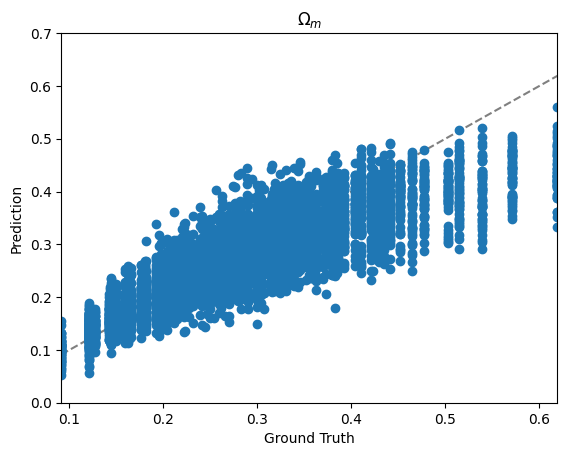

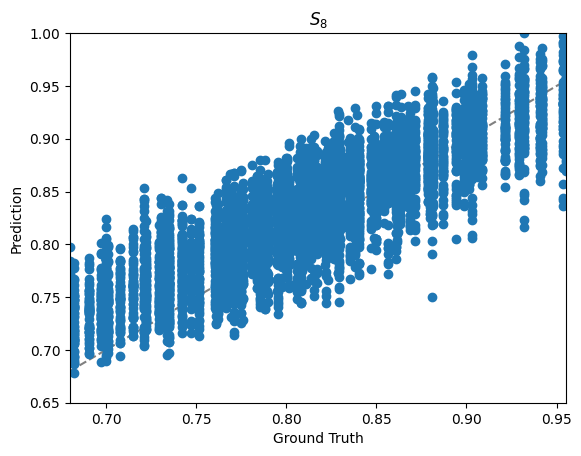

In [17]:
# Comparison of the means & standard deviations of the posterior distributions and the validation labels
all_val_labels_inv = label_scaler.inverse_transform(all_val_labels)
plt.errorbar(all_val_labels_inv[:,0], mean_val[:,0], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(all_val_labels_inv[:,0]), sorted(all_val_labels_inv[:,0]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(all_val_labels_inv[:,0]), np.max(all_val_labels_inv[:,0]))
plt.ylim(0, 0.7)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$\Omega_m$')
plt.show()

plt.errorbar(all_val_labels_inv[:,1], mean_val[:,1], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(all_val_labels_inv[:,1]), sorted(all_val_labels_inv[:,1]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(all_val_labels_inv[:,1]), np.max(all_val_labels_inv[:,1]))
plt.ylim(0.65, 1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$S_8$')
plt.show()

In [18]:
# Initialize Data class object
data_obj = Data(data_dir="./dataset", USE_PUBLIC_DATASET=True)

# Load train data
data_obj.load_train_data()

# Load test data
data_obj.load_test_data()

Loading WIDE12H_bin2_2arcmin_kappa.npy:   0%|          | 0/11 [00:00<?, ?it/s]

Loading WIDE12H_bin2_2arcmin_kappa.npy: 100%|██████████| 11/11 [22:56<00:00, 125.12s/it]
Loading WIDE12H_bin2_2arcmin_kappa_noisy_test.npy: 100%|██████████| 40/40 [01:20<00:00,  2.01s/it]


In [19]:
Ncosmo = data_obj.Ncosmo
Nsys = data_obj.Nsys

print(f'There are {Ncosmo} cosmological models, each has {Nsys} realizations of nuisance parameters in the training data.')

There are 101 cosmological models, each has 256 realizations of nuisance parameters in the training data.


In [20]:
# cosmology: (Ncosmo, 2)
# mean_val: (Nval, 2)
cosmology = data_obj.label[:,0,:2]   
dists = np.sum((all_val_labels_inv[:, None, :] - cosmology[None, :, :])**2, axis=2)  # (Nval, Ncosmo)
nearest_idx = np.argmin(dists, axis=1)  # for each validation sample, index of closest cosmology

# build index lists grouped by cosmology
index_lists = [[] for _ in range(cosmology.shape[0])]
for val_idx, cosmo_i in enumerate(nearest_idx):
    index_lists[cosmo_i].append(val_idx)

val_cosmology_idx = [np.array(lst, dtype=np.int32) for lst in index_lists]

In [21]:
# # There are Ncosmo distinct cosmologies in the labels.
# # Here we create a list that groups the indices of the validation instances with the same cosmological parameters

# cosmology = data_obj.label[:,0,:2]   # shape = (Ncosmo, 2)

# row_to_i = {tuple(cosmology[i]): i for i in range(Ncosmo)}
# index_lists = [[] for _ in range(cosmology.shape[0])]

# # Loop over each row in 'y_val' with shape = (Nval, 2)
# for idx in range(len(all_val_labels_inv)):
#     row_tuple = tuple(all_val_labels_inv[idx])
#     i = row_to_i[row_tuple]
#     index_lists[i].append(idx)

# # val_cosmology_idx[i] = the indices idx of the validation examples with labels = cosmology[i]
# val_cosmology_idx = [np.array(lst) for lst in index_lists]  

In [22]:
# The summary statistics of all realizations for all cosmologies in the validation set
d_vector = []  
n_d = 2   # Number of summary statistics for each map
for i in range(Ncosmo):
    d_i =  np.zeros((len(val_cosmology_idx[i]), n_d))  
    for j, idx in enumerate(val_cosmology_idx[i]):
        d_i[j] = mean_val[idx]

    d_vector.append(d_i)

In [23]:
# mean summary statistics (average over all realizations)
mean_d_vector = []
for i in range(Ncosmo):
    mean_d_vector.append(np.mean(d_vector[i], 0))
mean_d_vector = np.array(mean_d_vector)   

# covariance matrix
delta = []
for i in range(Ncosmo):
    delta.append((d_vector[i] - mean_d_vector[i].reshape(1, n_d))) 

cov_d_vector = [(delta[i].T @ delta[i] / (len(delta[i])-n_d-2))[None] for i in range(Ncosmo)]     
cov_d_vector = np.concatenate(cov_d_vector, 0) 

In [24]:
from scipy.interpolate import LinearNDInterpolator
mean_d_vector_interp = LinearNDInterpolator(cosmology, mean_d_vector, fill_value=np.nan)
cov_d_vector_interp = LinearNDInterpolator(cosmology, cov_d_vector, fill_value=np.nan)

In [25]:
logprior_interp = LinearNDInterpolator(cosmology, np.zeros((Ncosmo, 1)), fill_value=-np.inf)

# Note that the training data are not uniformly sampled, which introduces a prior distribution. Here we ignore that prior for simplicity.
# Also note that this prior would introduce bias for cosmologies at the boundary of the prior
def log_prior(x):
    logprior = logprior_interp(x).flatten()  # shape = (Ntest, ) 
    return logprior

# Gaussian likelihood with interpolated mean and covariance matrix
def loglike(x, d):
    mean = mean_d_vector_interp(x) 
    cov = cov_d_vector_interp(x)   
    delta = d - mean               
    
    inv_cov = np.linalg.inv(cov)
    cov_det = np.linalg.slogdet(cov)[1]
    
    return -0.5 * cov_det - 0.5 * np.einsum("ni,nij,nj->n", delta, inv_cov, delta)

def logp_posterior(x, d):
    logp = log_prior(x)
    select = np.isfinite(logp)
    if np.sum(select) > 0:
        logp[select] = logp[select] + loglike(x[select], d[select])
    return logp

In [26]:
Nval=all_val_labels_inv.shape[0]
print(Nval)

5656


In [27]:
mean_val.shape

(5656, 2)

In [28]:
# MCMC sampling to explore the posterior distribution

Nstep = 10000  # Number of MCMC steps (iterations)
sigma = 0.06   # Proposal standard deviation; should be tuned per method or parameter scale

# Randomly select initial points from the `cosmology` array for each test case
# Assumes `cosmology` has shape (Ncosmo, ndim) and `Ntest` is the number of independent chains/samples
current = cosmology[np.random.choice(Ncosmo, size=Nval)]

# Compute log-posterior at the initial points
curr_logprob = logp_posterior(current, mean_val)

# List to store sampled states (for all chains)
states = []

# Track total acceptance probabilities to compute acceptance rates
total_acc = np.zeros(len(current))

t = time.time()  # Track time for performance reporting

# MCMC loop
for i in range(Nstep):

    # Generate proposals by adding Gaussian noise to current state
    proposal = current + np.random.randn(*current.shape) * sigma    

    # Compute log-posterior at the proposed points
    proposal_logprob = logp_posterior(proposal, mean_val)

    # Compute log acceptance ratio (Metropolis-Hastings)
    acc_logprob = proposal_logprob - curr_logprob
    acc_logprob[acc_logprob > 0] = 0  # Cap at 0 to avoid exp overflow (acceptance prob ≤ 1)

    # Convert to acceptance probabilities
    acc_prob = np.exp(acc_logprob)

    # Decide whether to accept each proposal
    acc = np.random.uniform(size=len(current)) < acc_prob

    # Track acceptance probabilities (not binary outcomes)
    total_acc += acc_prob

    # Update states and log-probs where proposals are accepted
    current[acc] = proposal[acc]
    curr_logprob[acc] = proposal_logprob[acc]

    # Save a copy of the current state
    states.append(np.copy(current)[None])

    # Periodically print progress and acceptance rates
    if i % (0.1*Nstep) == 0.1*Nstep-1:
        print(
            'step:', len(states),
            'Time:', time.time() - t,
            'Min acceptance rate:', np.min(total_acc / (i + 1)),
            'Mean acceptance rate:', np.mean(total_acc / (i + 1))
        )
        t = time.time()  # Reset timer for next print interval

step: 1000 Time: 4.939195156097412 Min acceptance rate: 0.08123977384782773 Mean acceptance rate: 0.35105965144709006
step: 2000 Time: 4.969241380691528 Min acceptance rate: 0.07746291222384485 Mean acceptance rate: 0.35061070779634057
step: 3000 Time: 4.721857786178589 Min acceptance rate: 0.07994833906812679 Mean acceptance rate: 0.35046909508357915
step: 4000 Time: 4.775895833969116 Min acceptance rate: 0.075493051217709 Mean acceptance rate: 0.350401647450452
step: 5000 Time: 4.622272729873657 Min acceptance rate: 0.07480005820632611 Mean acceptance rate: 0.35037392676427276
step: 6000 Time: 4.624444961547852 Min acceptance rate: 0.07507873202808335 Mean acceptance rate: 0.350365470978549
step: 7000 Time: 4.703194856643677 Min acceptance rate: 0.07325797786362316 Mean acceptance rate: 0.3503356397289005
step: 8000 Time: 4.7698447704315186 Min acceptance rate: 0.07329454295070673 Mean acceptance rate: 0.35029995988463175
step: 9000 Time: 4.698764085769653 Min acceptance rate: 0.0719

step: 10000 Time: 4.785755634307861 Min acceptance rate: 0.07104673580232532 Mean acceptance rate: 0.35029247608856595


In [29]:
y_pred_val=mean_val

In [30]:
# remove burn-in
states = np.concatenate(states[int(0.2*Nstep):], 0)

# mean and std of samples
mean_val = np.mean(states, 0)
errorbar_val = np.std(states, 0)

In [31]:
mean_val

array([[0.37466008, 0.776545  ],
       [0.18484425, 0.92028304],
       [0.46803291, 0.73316934],
       ...,
       [0.14782802, 0.72112619],
       [0.25759023, 0.76969061],
       [0.33378052, 0.70233764]], shape=(5656, 2))

In [32]:
y_val=all_val_labels_inv

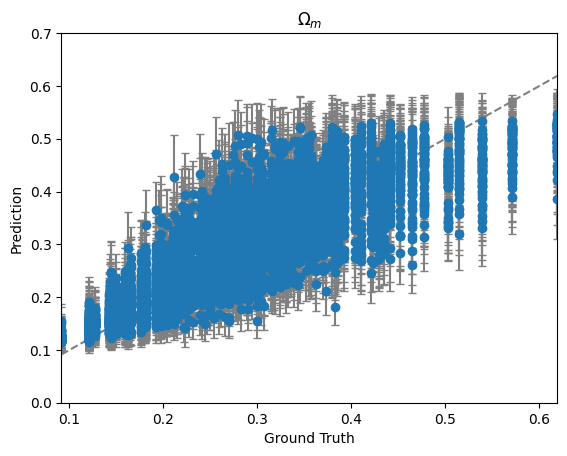

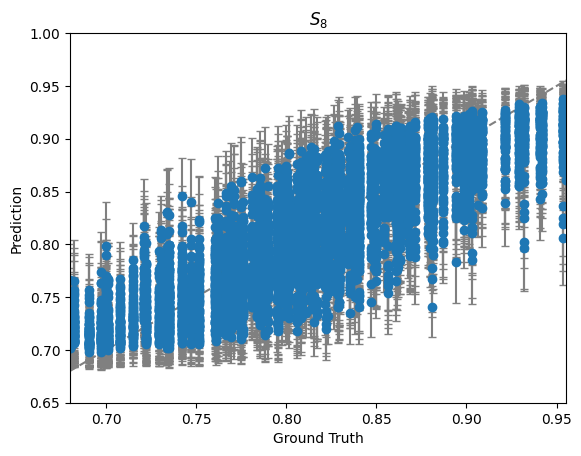

In [33]:
# Comparison of the means & standard deviations of the posterior distributions and the validation labels

plt.errorbar(y_val[:,0], mean_val[:,0], yerr=errorbar_val[:,0], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,0]), sorted(y_val[:,0]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,0]), np.max(y_val[:,0]))
plt.ylim(0, 0.7)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$\Omega_m$')
plt.show()

plt.errorbar(y_val[:,1], mean_val[:,1], yerr=errorbar_val[:,1], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,1]), sorted(y_val[:,1]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,1]), np.max(y_val[:,1]))
plt.ylim(0.65, 1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$S_8$')
plt.show()

In [34]:
validation_score = Score._score_phase1(
    true_cosmo=y_val,
    infer_cosmo=mean_val,
    errorbar=errorbar_val
)
print('averaged score:', np.mean(validation_score))
print('averaged error bar:', np.mean(errorbar_val, 0))

averaged score: 6.186427649122266
averaged error bar: [0.05759142 0.03385242]


In [35]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [36]:
model.eval()
y_pred_list = []   
pbar = tqdm(test_loader, total=len(test_loader), desc="Inference on the test set")
with torch.no_grad():
    for X in pbar:
        X = X.to(config.DEVICE)
        y_pred = model(X)        
        y_pred = label_scaler.inverse_transform(y_pred.cpu().numpy())
        y_pred_list.append(y_pred) 

y_pred_test = np.concatenate(y_pred_list, axis=0)

Inference on the test set: 100%|██████████| 40/40 [00:21<00:00,  1.86it/s]


In [37]:
y_pred_test

array([[0.3185078 , 0.82879984],
       [0.23258546, 0.9190471 ],
       [0.21727066, 0.9186596 ],
       ...,
       [0.28351682, 0.8695343 ],
       [0.3632395 , 0.7280445 ],
       [0.36862746, 0.9491842 ]], shape=(4000, 2), dtype=float32)

In [38]:
# MCMC sampling to explore the posterior distribution

Nstep = 10000  # Number of MCMC steps (iterations)
sigma = 0.06   # Proposal standard deviation; should be tuned per method or parameter scale

# Randomly select initial points from the `cosmology` array for each test case
# Assumes `cosmology` has shape (Ncosmo, ndim) and `Ntest` is the number of independent chains/samples
current = cosmology[np.random.choice(Ncosmo, size=data_obj.Ntest)]

# Compute log-posterior at the initial points
curr_logprob = logp_posterior(current, y_pred_test)

# List to store sampled states (for all chains)
states = []

# Track total acceptance probabilities to compute acceptance rates
total_acc = np.zeros(len(current))

t = time.time()  # Track time for performance reporting

# MCMC loop
for i in range(Nstep):

    # Generate proposals by adding Gaussian noise to current state
    proposal = current + np.random.randn(*current.shape) * sigma    

    # Compute log-posterior at the proposed points
    proposal_logprob = logp_posterior(proposal, y_pred_test)

    # Compute log acceptance ratio (Metropolis-Hastings)
    acc_logprob = proposal_logprob - curr_logprob
    acc_logprob[acc_logprob > 0] = 0  # Cap at 0 to avoid exp overflow (acceptance prob ≤ 1)

    # Convert to acceptance probabilities
    acc_prob = np.exp(acc_logprob)

    # Decide whether to accept each proposal
    acc = np.random.uniform(size=len(current)) < acc_prob

    # Track acceptance probabilities (not binary outcomes)
    total_acc += acc_prob

    # Update states and log-probs where proposals are accepted
    current[acc] = proposal[acc]
    curr_logprob[acc] = proposal_logprob[acc]

    # Save a copy of the current state
    states.append(np.copy(current)[None])

    # Periodically print progress and acceptance rates
    if i % (0.1*Nstep) == 0.1*Nstep-1:
        print(
            'step:', len(states),
            'Time:', time.time() - t,
            'Min acceptance rate:', np.min(total_acc / (i + 1)),
            'Mean acceptance rate:', np.mean(total_acc / (i + 1))
        )
        t = time.time()  # Reset timer for next print interval

step: 1000 Time: 3.4660871028900146 Min acceptance rate: 0.0780071424270313 Mean acceptance rate: 0.3512565038766243
step: 2000 Time: 3.483795166015625 Min acceptance rate: 0.07999115540450132 Mean acceptance rate: 0.35073220432543367
step: 3000 Time: 3.31559419631958 Min acceptance rate: 0.08095430396023892 Mean acceptance rate: 0.3504943217052722
step: 4000 Time: 3.321942090988159 Min acceptance rate: 0.08272317345111607 Mean acceptance rate: 0.35044072915299057
step: 5000 Time: 3.3277854919433594 Min acceptance rate: 0.0795501653837275 Mean acceptance rate: 0.35047787057880064
step: 6000 Time: 3.349372625350952 Min acceptance rate: 0.07850522920247306 Mean acceptance rate: 0.3504860632273995
step: 7000 Time: 3.3732357025146484 Min acceptance rate: 0.07750250809860998 Mean acceptance rate: 0.350473479563235
step: 8000 Time: 3.356428861618042 Min acceptance rate: 0.0779495178675677 Mean acceptance rate: 0.35048019718044787
step: 9000 Time: 3.402796983718872 Min acceptance rate: 0.0796

In [39]:
# remove burn-in
states = np.concatenate(states[int(0.2*Nstep):], 0)

# mean and std of samples
mean = np.mean(states, 0)
errorbar = np.std(states, 0)

In [40]:
states

array([[[0.29099372, 0.82248857],
        [0.23765112, 0.91785394],
        [0.18562395, 0.92113802],
        ...,
        [0.29712899, 0.87523997],
        [0.39930486, 0.72316077],
        [0.37093804, 0.92764835]],

       [[0.34961831, 0.78346556],
        [0.23765112, 0.91785394],
        [0.18562395, 0.92113802],
        ...,
        [0.2644119 , 0.94113673],
        [0.39930486, 0.72316077],
        [0.37093804, 0.92764835]],

       [[0.34961831, 0.78346556],
        [0.23765112, 0.91785394],
        [0.18562395, 0.92113802],
        ...,
        [0.2644119 , 0.94113673],
        [0.39930486, 0.72316077],
        [0.37093804, 0.92764835]],

       ...,

       [[0.24872616, 0.85431612],
        [0.33805013, 0.89157779],
        [0.31427515, 0.87951583],
        ...,
        [0.34643435, 0.84877806],
        [0.37741117, 0.75181652],
        [0.44662021, 0.89171821]],

       [[0.24375785, 0.83823551],
        [0.33805013, 0.89157779],
        [0.31427515, 0.87951583],
        .

In [41]:
mean

array([[0.36713825, 0.80028755],
       [0.24563662, 0.90848075],
       [0.22680713, 0.90801812],
       ...,
       [0.31185929, 0.85627861],
       [0.39749753, 0.70908534],
       [0.3604739 , 0.91345612]], shape=(4000, 2))

In [42]:
data = {"means": mean.tolist(), "errorbars": errorbar.tolist()}
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = 'Submission_' + the_date + '.zip'
zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data
)
print(f"Submission ZIP saved at: {zip_file}")

Submission ZIP saved at: submissions/Submission_25-09-20-14-54.zip
